## Step 2: Data Collection

###Import Necessary Libraries

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.models import Sequential,load_model
from keras.layers import Dense,Flatten
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

###Load Dataset

In [6]:
!unzip -q cifar-10.zip -d cifar10

In [7]:
!ls -R cifar10 | head -50

cifar10:
sampleSubmission.csv
test.7z
train.7z
trainLabels.csv


In [8]:
!apt-get install -y p7zip-full

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [9]:
!7z x cifar10/train.7z -ocifar10/train


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 109723070 bytes (105 MiB)

Extracting archive: cifar10/train.7z
--
Path = cifar10/train.7z
Type = 7z
Physical Size = 109723070
Headers Size = 294768
Method = LZMA:26
Solid = +
Blocks = 1

  0%      2%      2% 679 - train/10609.png                            2% 1168 - train/11049.png                             2% 1542 - train/11386.png                             2% 1843 - train/11657.png                             6% 1868 - train/1168.png                         

In [10]:
!ls cifar10/train/train | head

10000.png
10001.png
10002.png
10003.png
10004.png
10005.png
10006.png
10007.png
10008.png
10009.png


In [11]:
import pandas as pd

labels = pd.read_csv("cifar10/trainLabels.csv")
labels.head()

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


In [12]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Read labels
labels = pd.read_csv("cifar10/trainLabels.csv")

# Folder containing the extracted images
image_dir = "cifar10/train/train"

# Class mapping
class_names = sorted(labels["label"].unique())
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

X = []
y = []

for _, row in labels.iterrows():
    img_path = os.path.join(image_dir, f"{row['id']}.png")
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    X.append(img)
    y.append(class_to_idx[row["label"]])

X = np.array(X, dtype=np.uint8)
y = np.array(y)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##Step 3: Data Understanding

In [18]:
X_train.shape,y_train.shape

((40000, 32, 32, 3), (40000,))

In [19]:
X_test.shape,y_test.shape

((10000, 32, 32, 3), (10000,))

In [20]:
X_train[10].shape

(32, 32, 3)

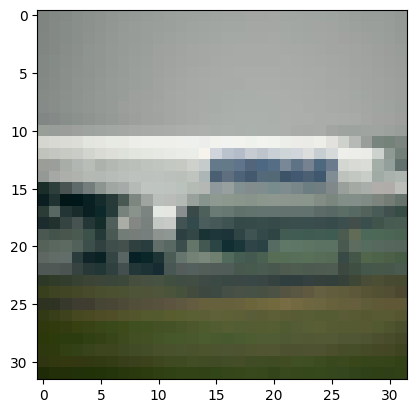

airplane


In [27]:
plt.imshow(X_train[17])
plt.show()
print(class_names[y_train[17]])

##Step 4: Data Preparation

In [30]:
X_train.min(),X_train.max()
X_train = X_train/255.0
X_test = X_test/255.0

In [31]:
X_train.min(),X_train.max()

(np.float64(0.0), np.float64(1.0))

##Step 5: Model Building

In [38]:
model = Sequential([
    keras.layers.Input(shape=(32,32,3)),
    Flatten(),
    Dense(512,activation='relu'),
    Dense(256,activation='relu'),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
    ])


In [39]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

##Step 6: Model Training || Step 7: Model Testing || Step 8: Model Evaluation

In [42]:
model.fit(x=X_train,y=y_train,batch_size=32,epochs=14,validation_data=(X_test,y_test))

Epoch 1/14
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.6882 - loss: 0.8605 - val_accuracy: 0.4924 - val_loss: 1.8379
Epoch 2/14
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.6938 - loss: 0.8469 - val_accuracy: 0.4870 - val_loss: 1.8821
Epoch 3/14
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.6977 - loss: 0.8362 - val_accuracy: 0.4849 - val_loss: 1.9073
Epoch 4/14
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.7011 - loss: 0.8258 - val_accuracy: 0.4758 - val_loss: 2.0148
Epoch 5/14
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.6993 - loss: 0.8292 - val_accuracy: 0.4821 - val_loss: 1.9937
Epoch 6/14
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.7030 - loss: 0.8198 - val_accuracy: 0.4887 - val_loss: 1.9333
Epoch 7/14
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - accuracy: 0.7072 - loss: 0.8048 - val_accuracy: 0.4835 - val_loss: 2.0010
Epoch 8/14
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 37s 30ms/step - accuracy: 0.7143 -

###Model Prediction

In [44]:
y_pred = model.predict(X_test)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


array([[7.3721990e-02, 7.3431021e-09, 9.2106670e-01, ..., 2.1334147e-04,
        8.1739802e-04, 3.8804689e-08],
       [2.2779372e-05, 2.4665198e-06, 4.4497098e-03, ..., 9.9446416e-01,
        1.0521007e-06, 6.9578287e-05],
       [2.0569693e-01, 1.5109852e-01, 4.6536945e-02, ..., 6.1527863e-03,
        7.4523084e-02, 5.0839317e-01],
       ...,
       [2.8936003e-04, 2.2256724e-03, 1.7541898e-02, ..., 1.5510070e-04,
        7.2570634e-03, 3.2022505e-03],
       [5.4123204e-02, 2.2161044e-05, 2.7537042e-02, ..., 1.5180130e-02,
        1.3475161e-03, 3.5793823e-01],
       [7.2476512e-01, 4.3916274e-03, 1.0951279e-01, ..., 1.6670622e-02,
        5.7292864e-02, 2.7868407e-02]], dtype=float32)

###Evaluation

In [45]:
loss,accuracy = model.evaluate(X_test,y_test)
print('Test Accuracy:',accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4839 - loss: 2.1914
Test Accuracy: 0.4839000105857849


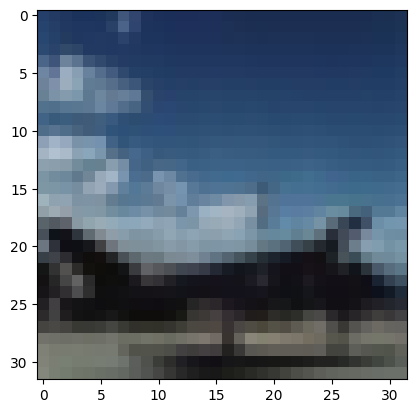

In [46]:
plt.imshow(X_test[400])

In [47]:
np.argmax(y_pred[400])

np.int64(1)

In [48]:
model.save('cifar10_intelligence.h5')

In [49]:
cifar_intelligence = load_model('cifar10_intelligence.h5')

In [57]:
from PIL import Image
image_path = r'/content/Screenshot 2026-07-18 133438.png'
image = Image.open(image_path).convert('RGB').resize(size=(32,32))
image = np.array(image)
image = image / 255.0
image = np.expand_dims(image, axis=0)
print(image.shape)
prediction = cifar_intelligence.predict(image)
predicted_class = np.argmax(prediction)
confidence = np.max(prediction)
print("Predicted Class :", class_names[predicted_class])
print('Confidence:',round(confidence*100,2),'%')


(1, 32, 32, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Class : deer
Confidence: 63.96 %
